In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

In [2]:
np.random.seed(1234567)

In [63]:
def model(x, y, a=1, b=1):
    return (x ** 2 + y ** 2) ** 2 - 2 * b ** 2 * (x ** 2 - y ** 2) - (a ** 4 - b ** 4) 

In [70]:
xlin = np.linspace(-3, 3, 200)
ylin = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(xlin, ylin)

In [71]:
Z = model(X, Y)

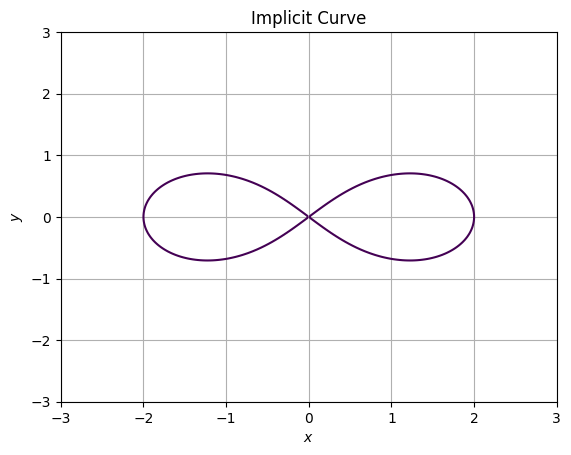

In [72]:
fig, axe = plt.subplots()
c = axe.contour(X, Y, Z, [0])
axe.set_title("Implicit Curve")
axe.set_xlabel("$x$")
axe.set_ylabel("$y$")
axe.grid()

In [73]:
data = c.get_paths()[0].vertices
data += 0.1 * np.random.normal(size=data.shape)

In [74]:
def loss_factory(x, y):
    def wrapped(parameters):
        return 0.5 * np.sum(model(x, y, *parameters) ** 2)
    return wrapped

In [75]:
loss = loss_factory(*data.T)

In [76]:
sol = optimize.minimize(loss, x0=[1, 1])
sol

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 64.80493893711045
        x: [ 1.010e+00  1.005e+00]
      nit: 6
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[ 1.374e-04 -1.907e-05]
            [-1.907e-05  6.667e-05]]
     nfev: 27
     njev: 9

In [77]:
Zhat = model(X, Y, *sol.x)

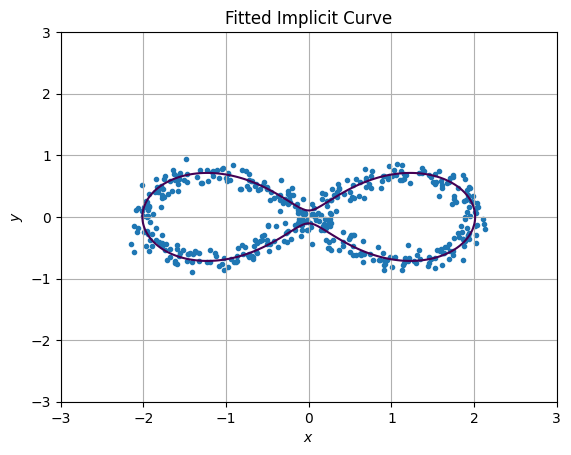

In [78]:
fig, axe = plt.subplots()
axe.scatter(*data.T, marker=".")
axe.contour(X, Y, Zhat, [0])
axe.set_title("Fitted Implicit Curve")
axe.set_xlabel("$x$")
axe.set_ylabel("$y$")
axe.grid()

In [79]:
alin = np.linspace(-5, 5, 200)
blin = np.linspace(-5, 5, 200)
A, B = np.meshgrid(alin, blin)

In [80]:
def loss_factory_2(x, y):
    @np.vectorize
    def wrapped(a, b):
        return 0.5 * np.sum(model(x, y, a, b) ** 2)
    return wrapped

In [81]:
loss2 = loss_factory_2(*data.T)

In [82]:
L = loss2(A, B)

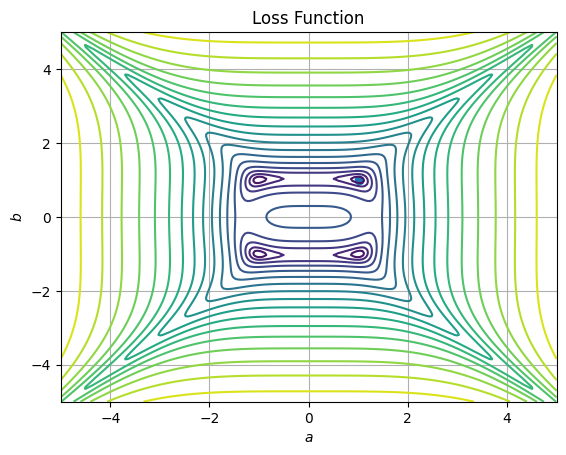

In [83]:
fig, axe = plt.subplots()
axe.contour(A, B, np.log(L), 20)
axe.scatter(*sol.x)
axe.set_title("Loss Function")
axe.set_xlabel("$a$")
axe.set_ylabel("$b$")
axe.grid()